In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [61]:
im1 = cv2.cvtColor(cv2.imread("media/doorleft.jpg"), cv2.COLOR_BGR2RGB)
im2 = cv2.cvtColor(cv2.imread("media/doorright.jpg"), cv2.COLOR_BGR2RGB)

Used online photo editing tool to determine the x,y coordinates of points of correspondence, then uploaded them here

In [62]:
im1_pts = np.array([[2716,1339],[4184,1134],[2031,1583],[2441,1915],[2114,4895],[2504,4301],[4009,3570],[4234,3934],[2557,2640],[2569,3055]])
im2_pts = np.array([[1513,1314],[2846,1287],[783,1475],[1234,1863],[846,4949],[1271,4285],[2671,3497],[2854,3811],[1359,2613],[1367,3036]])


In [24]:
def computeH(im1_pts, im2_pts): #using least squares bec more than 4 correspondences produce an overdetermined system
    assert im1_pts.shape == im2_pts.shape
    N = im1_pts.shape[0]
    A = []

    for i in range(N):
        x, y = im1_pts[i, 0], im1_pts[i, 1]
        x_p, y_p = im2_pts[i, 0], im2_pts[i, 1]
        A.append([-x, -y, -1, 0, 0, 0, x*x_p, y*x_p, x_p])
        A.append([0, 0, 0, -x, -y, -1, x*y_p, y*y_p, y_p]) #system of equations

    A = np.asarray(A)
    # Solve Ah = 0 homogeneous system
    U, S, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)
    H /= H[2, 2] 
    return H

In [25]:
H = computeH(im1_pts, im2_pts)
print("Recovered 3x3 homography matrix:\n", H)

Recovered 3x3 homography matrix:
 [[ 1.42939294e+00 -6.37927832e-03 -1.94020335e+03]
 [ 2.92077918e-01  1.29115243e+00 -8.57457025e+02]
 [ 9.81519543e-05  4.35146266e-06  1.00000000e+00]]


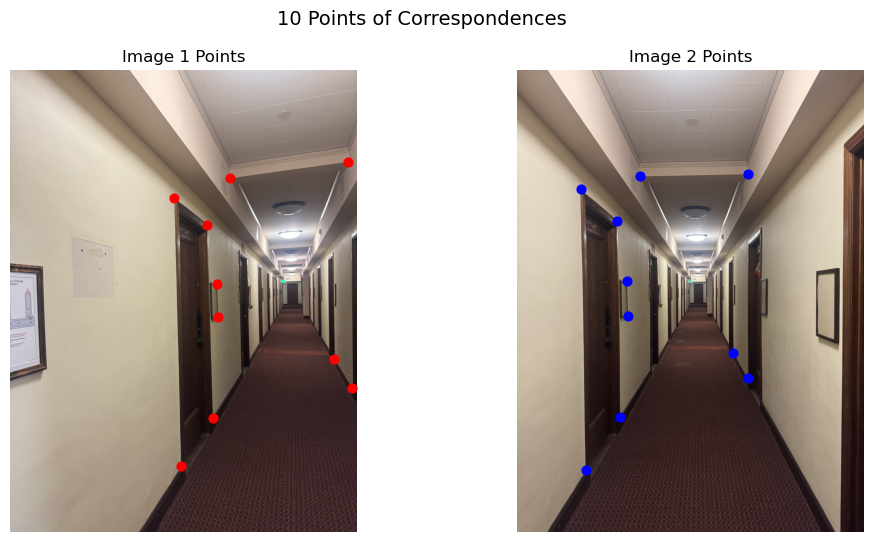

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(im1); axes[0].scatter(im1_pts[:,0], im1_pts[:,1], c="r", s=40)
axes[0].set_title("Image 1 Points"); axes[0].axis("off")

axes[1].imshow(im2); axes[1].scatter(im2_pts[:,0], im2_pts[:,1], c="b", s=40)
axes[1].set_title("Image 2 Points"); axes[1].axis("off")
plt.suptitle("10 Points of Correspondences", fontsize=14)
plt.show()

In [65]:
imm1 = cv2.cvtColor(cv2.imread("media/iceleft.jpg"), cv2.COLOR_BGR2RGB)
imm2 = cv2.cvtColor(cv2.imread("media/iceright.jpg"), cv2.COLOR_BGR2RGB)

In [83]:
imm1_pts = np.array([[2777,2362],[4171,2371],[2319,2944],[3039,2809],[3259,2802],[2566,3056],[2999,3278],[2700,4405]])
imm2_pts = np.array([[1131,2259],[2392,2356],[620,2856],[1406,2724],[1613,2722],[902,2975],[1353,3193],[1026,4343]])


In [67]:
HH = computeH(imm1_pts, imm2_pts)
print("Recovered 3x3 homography matrix:\n", HH)

Recovered 3x3 homography matrix:
 [[-1.92264862e-01 -1.95726322e-01  1.22503862e+03]
 [-4.75895628e-01 -4.62803439e-01  2.97851325e+03]
 [-1.64912357e-04 -1.45534264e-04  1.00000000e+00]]


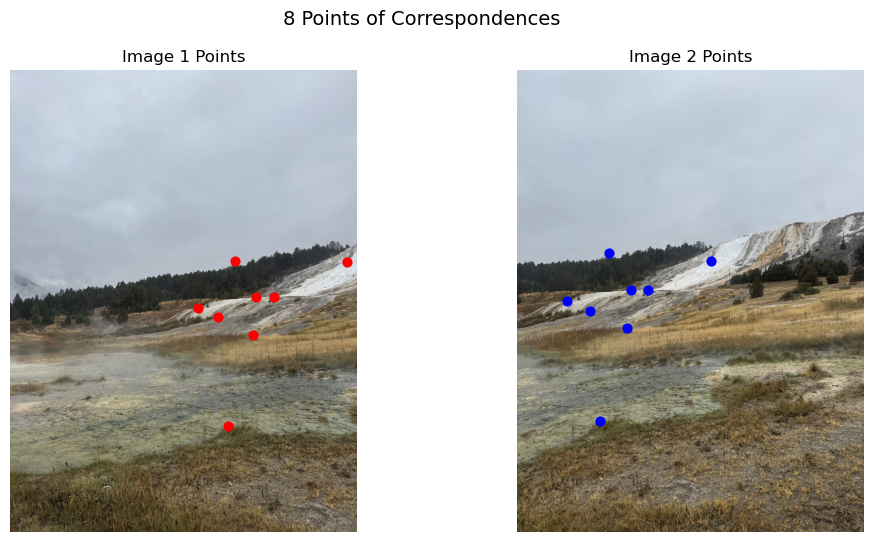

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(imm1); axes[0].scatter(imm1_pts[:,0], imm1_pts[:,1], c="r", s=40)
axes[0].set_title("Image 1 Points"); axes[0].axis("off")

axes[1].imshow(imm2); axes[1].scatter(imm2_pts[:,0], imm2_pts[:,1], c="b", s=40)
axes[1].set_title("Image 2 Points"); axes[1].axis("off")
plt.suptitle("8 Points of Correspondences", fontsize=14)
plt.show()

In [26]:
def warp_bound(im,H):
    h, w = im.shape[:2]
    corners = np.array([[0,0,1], [w,0,1], [0,h,1], [w,h,1]]).T  # 3x4
    warped_corners = H @ corners
    warped_corners /= warped_corners[2,:]
    min_x, max_x = warped_corners[0].min(), warped_corners[0].max()
    min_y, max_y = warped_corners[1].min(), warped_corners[1].max()
    return min_x, max_x, min_y, max_y

In [8]:
# using nearest neighbours warping method
def warpImageNearestNeighbor(im, H):
    h, w = im.shape[:2]
    Hinv = np.linalg.inv(H)

    min_x, max_x, min_y, max_y = warp_bound(im, H)
    out_w, out_h = int(np.ceil(max_x - min_x)), int(np.ceil(max_y - min_y))

    imwarped = np.zeros((out_h, out_w, 3), dtype=np.uint8)

    for y_out in range(out_h):
        for x_out in range(out_w):
            # map output pixel (x_out + min_x, y_out + min_y) -> input
            target = np.array([x_out + min_x, y_out + min_y, 1])
            src = Hinv @ target
            src /= src[2]

            x_src, y_src = src[0], src[1]
            if 0 <= x_src < w and 0 <= y_src < h:
                x_nn, y_nn = int(round(x_src)), int(round(y_src))
                if x_nn < w and y_nn < h:
                    imwarped[y_out, x_out] = im[int(y_nn), int(x_nn)]
    return imwarped

In [27]:
# using bilinear interpolation warping method
def warpImageBilinear(im, H):
    h, w = im.shape[:2]
    Hinv = np.linalg.inv(H)

    min_x, max_x, min_y, max_y = warp_bound(im, H)
    out_w, out_h = int(np.ceil(max_x - min_x)), int(np.ceil(max_y - min_y))
    imwarped = np.zeros((out_h, out_w, 3), dtype=np.uint8)

    for y_out in range(out_h):
        for x_out in range(out_w):
            target = np.array([x_out + min_x, y_out + min_y, 1])
            src = Hinv @ target
            src /= src[2]

            x_src, y_src = src[0], src[1]
            if 0 <= x_src < w - 1 and 0 <= y_src < h - 1:
                x0, y0 = int(np.floor(x_src)), int(np.floor(y_src))
                dx, dy = x_src - x0, y_src - y0

                # nearest 4 neighbouring pixel
                top_left = im[y0, x0]
                top_right = im[y0, x0 + 1]
                bottom_left = im[y0 + 1, x0]
                bottom_right = im[y0 + 1, x0 + 1]

                # taking thier weighted average
                top = (1 - dx) * top_left + dx * top_right
                bottom = (1 - dx) * bottom_left + dx * bottom_right
                value = (1 - dy) * top + dy * bottom

                imwarped[y_out, x_out] = np.clip(value, 0, 255)
    return imwarped


In [30]:
# will be using a picture of a painting
im = cv2.cvtColor(cv2.imread("media/monalisa.png"), cv2.COLOR_BGR2RGB)

In [ ]:
im_pts = np.array([[96,60],[882,162],[970,1253],[145,1325]])
im_frame = np.array([[0,0],[600,0],[600,800],[0,800]])
H = computeH(im_pts,im_frame)

(np.float64(-0.5), np.float64(828.5), np.float64(1025.5), np.float64(-0.5))

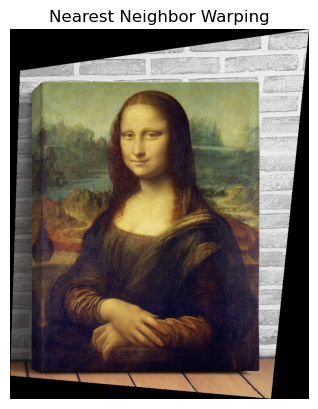

In [37]:
im_nn = warpImageNearestNeighbor(im, H)
plt.imshow(im_nn)
plt.title("Nearest Neighbor Warping")
plt.axis("off")

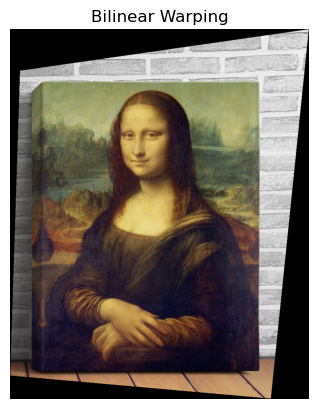

In [38]:
im_bil = warpImageBilinear(im, H)
plt.imshow(im_bil)
plt.title("Bilinear Warping")
plt.axis("off")
plt.show()

In [47]:
imtwo = cv2.cvtColor(cv2.imread("media/kento.jpg"), cv2.COLOR_BGR2RGB)

In [57]:
imtwo_pts = np.array([[1915,1466],[2486,2279],[965,2925],[487,2018]])
imtwo_frame = np.array([[0,0],[100,0],[100,150],[0,150]])
Htwo = computeH(imtwo_pts,imtwo_frame)

(np.float64(-0.5), np.float64(521.5), np.float64(474.5), np.float64(-0.5))

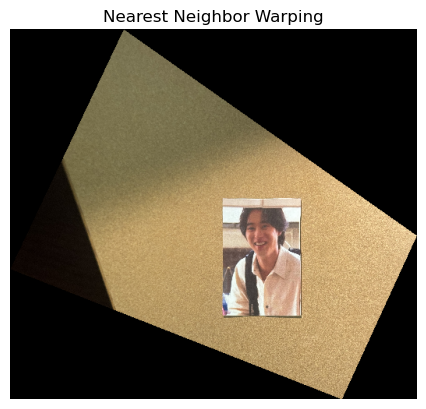

In [58]:
im2_nn = warpImageNearestNeighbor(imtwo, Htwo)
plt.imshow(im2_nn)
plt.title("Nearest Neighbor Warping")
plt.axis("off")

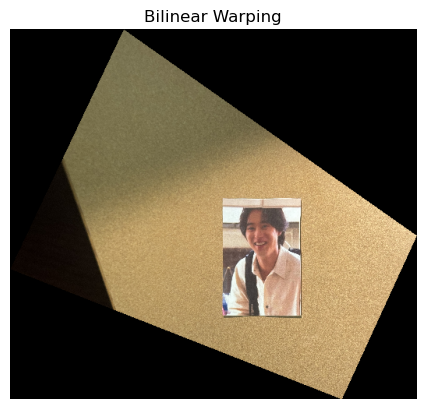

In [59]:
imtwo_bil = warpImageBilinear(imtwo, Htwo)
plt.imshow(imtwo_bil)
plt.title("Bilinear Warping")
plt.axis("off")
plt.show()